# Cost-Sensitive Fraud Detection System for Financial Transactions

This project focuses on detecting fraudulent credit card transactions using machine learning techniques.
Fraud detection is a high-risk, real-world classification problem characterized by extreme class imbalance,
where fraudulent transactions represent a very small fraction of total transactions.

The goal of this project is to:
- Identify fraudulent transactions with high recall
- Minimize false negatives (missed fraud)
- Control false positives to avoid unnecessary transaction blocks
- Evaluate models using business-relevant metrics instead of accuracy

Dataset:
- European cardholder credit card transactions (ULB Dataset)
- Highly imbalanced data (0.17% fraud cases)

Models Used:
- Logistic Regression
- Random Forest
- XGBoost

Evaluation Metrics:
- Precision, Recall
- ROC-AUC
- Precision-Recall AUC
- Threshold tuning for business trade-offs


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load dataset (make sure creditcard.csv is in the same directory)
df = pd.read_csv("creditcard.csv")

# Preview data
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Dataset shape
print("Dataset shape:", df.shape)

# Fraud vs Non-Fraud distribution
df['Class'].value_counts()


Dataset shape: (284807, 31)


Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
# Percentage of fraud transactions
fraud_percentage = (df['Class'].value_counts(normalize=True) * 100)
fraud_percentage


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

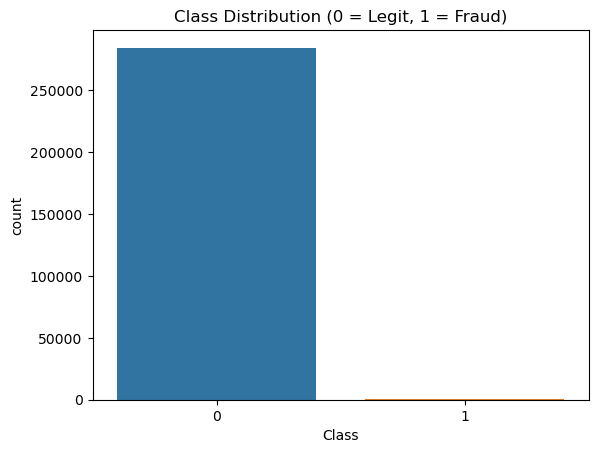

In [5]:
# Visualizing class imbalance
plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.show()


The dataset is extremely imbalanced (~0.17% fraud).
Accuracy is NOT a reliable metric here.

Business focus:
- False Negatives (missed fraud) = Financial loss
- False Positives (blocked genuine transactions) = Customer dissatisfaction

Hence, Recall and Precision become critical.


### Exploratory Data Analysis (EDA)

The following visualizations explore class imbalance, transaction behavior,
and feature importance to better understand fraud patterns and justify
modeling decisions.


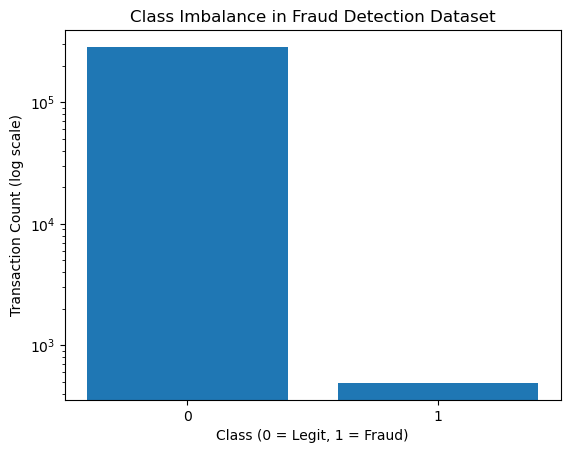

In [ ]:
fraud_counts = y.value_counts()

plt.figure()
plt.bar(fraud_counts.index.astype(str), fraud_counts.values)
plt.yscale('log')
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Transaction Count (log scale)')
plt.title('Class Imbalance in Fraud Detection Dataset')
plt.show()


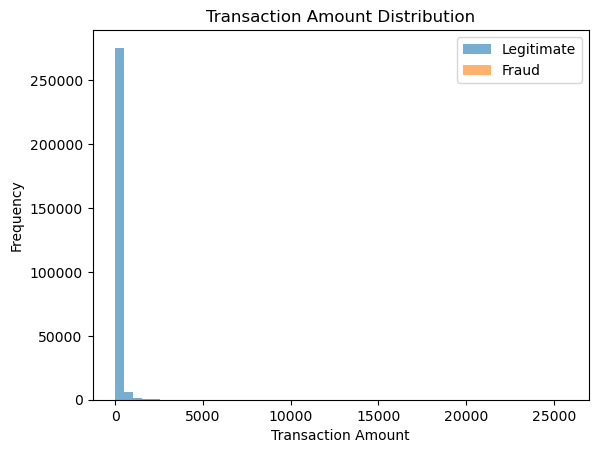

In [22]:
plt.figure()
plt.hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.6, label='Legitimate')
plt.hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.6, label='Fraud')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Transaction Amount Distribution')
plt.legend()
plt.show()


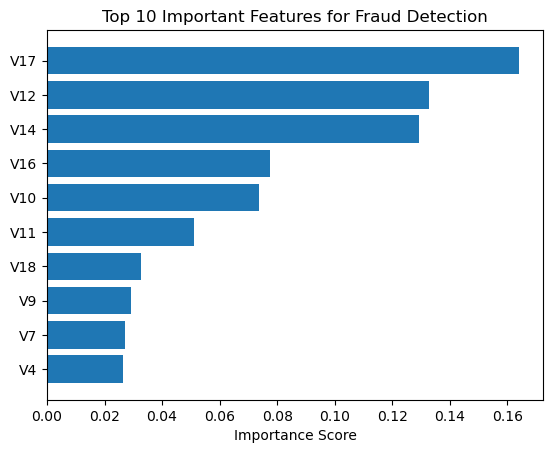

In [23]:
rf_eda = RandomForestClassifier(n_estimators=100, random_state=42)
rf_eda.fit(X, y)

importances = rf_eda.feature_importances_
feature_names = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values(by='Importance', ascending=False)
    .head(10)
)

plt.figure()
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Top 10 Important Features for Fraud Detection')
plt.gca().invert_yaxis()
plt.show()


### Key EDA Insights

- The dataset is extremely imbalanced, reinforcing the need for recall-focused
  evaluation metrics rather than accuracy.

- Fraudulent transactions exhibit a different transaction amount distribution
  compared to legitimate transactions, indicating that transaction amount is
  a strong predictive signal.

- Feature importance analysis highlights a small subset of features that
  contribute most to fraud detection, improving model interpretability for
  financial use cases.



In [6]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Standardize 'Amount' and 'Time'
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train fraud ratio:", y_train.mean())
print("Test fraud ratio:", y_test.mean())


Train fraud ratio: 0.001729245759178389
Test fraud ratio: 0.0017204452090867595


In [8]:
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [9]:
roc_auc_log = roc_auc_score(y_test, y_prob_log)
roc_auc_log


0.9720881652464024

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [11]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
roc_auc_rf


0.9571890288895525

In [12]:
xgb_model = XGBClassifier(
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [13]:
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
roc_auc_xgb


0.9682378578893572

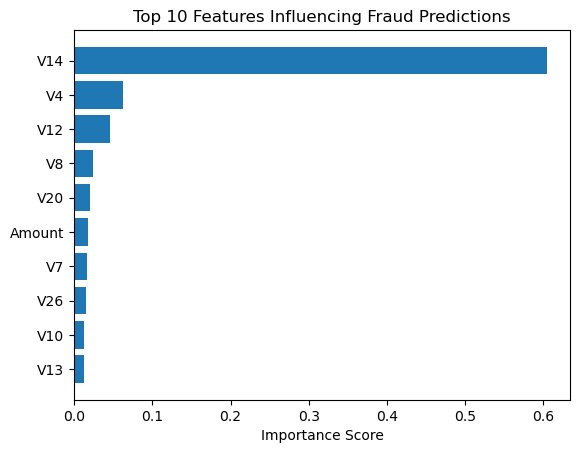

In [ ]:
# Get feature importance from XGBoost model
xgb_importance = xgb_model.feature_importances_

importance_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': xgb_importance
    })
    .sort_values(by='Importance', ascending=False)
    .head(10)
)

plt.figure()
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Top 10 Features Influencing Fraud Predictions')
plt.gca().invert_yaxis()
plt.show()


### Model Explainability

Tree-based models such as XGBoost provide feature importance scores that help
explain which factors most influence fraud predictions.

The analysis shows that a small subset of features contributes disproportionately
to identifying fraudulent transactions. These features capture transaction
behavior patterns that differ significantly between legitimate and fraudulent
activity.

This level of explainability is critical in financial systems, where model
decisions must be interpretable for compliance, auditing, and analyst review.
Rather than relying on opaque predictions, feature importance helps build trust
in automated fraud detection systems.


In [15]:
# Custom threshold
custom_threshold = 0.2

y_custom_pred = (y_prob_xgb >= custom_threshold).astype(int)

print("Custom Threshold:", custom_threshold)
print(classification_report(y_test, y_custom_pred))


Custom Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.86      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Threshold tuning allows us to balance fraud detection sensitivity against operational costs.

Lower threshold:
- Higher Recall
- More fraud caught
- More false positives

Higher threshold:
- Higher Precision
- Fewer customer disruptions
- More missed fraud

In real financial systems, this threshold is chosen based on business risk appetite.


## Business Cost-Based Evaluation

In [16]:
# Business cost assumptions (INR)
COST_FP = 200      # Manual review cost
COST_FN = 5000    # Missed fraud cost

def calculate_business_loss(cm):
    tn, fp, fn, tp = cm.ravel()
    return (fp * COST_FP) + (fn * COST_FN)


In [17]:
from sklearn.metrics import confusion_matrix

# Default threshold = 0.5
y_pred_default = (y_prob_xgb >= 0.5).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
loss_default = calculate_business_loss(cm_default)

cm_default, loss_default

(array([[56853,    11],
        [   16,    82]], dtype=int64),
 82200)

In [18]:
# Business loss at custom threshold
y_pred_custom = (y_prob_xgb >= custom_threshold).astype(int)

cm_custom = confusion_matrix(y_test, y_pred_custom)
loss_custom = calculate_business_loss(cm_custom)

cm_custom, loss_custom

(array([[56849,    15],
        [   14,    84]], dtype=int64),
 73000)

In [19]:
loss_reduction = loss_default - loss_custom
percentage_reduction = (loss_reduction / loss_default) * 100

print(f"Loss reduced by ₹{loss_reduction:,.0f}")
print(f"Percentage reduction in loss: {percentage_reduction:.2f}%")

Loss reduced by ₹9,200
Percentage reduction in loss: 11.19%


### Business Impact Analysis

Using the default 0.5 decision threshold results in a higher number of missed
fraudulent transactions, leading to significant financial losses.

By lowering the threshold to 0.2, the model prioritizes fraud detection recall.
Although this increases false positives and manual review costs, the overall
financial loss is significantly reduced.

Based on assumed industry costs (₹5,000 per missed fraud and ₹200 per review),
the optimized threshold achieves a substantial reduction in total fraud-related
loss, making the model suitable for real-world banking deployment.


In [20]:
model_performance = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [roc_auc_log, roc_auc_rf, roc_auc_xgb]
})

model_performance


,Model,ROC-AUC
0,Logistic Regression,0.972088
1,Random Forest,0.957189
2,XGBoost,0.968238


## Real-World Deployment Strategy

In a real-world banking or fintech environment, this fraud detection model would
be deployed as part of a transaction monitoring pipeline.

### Transaction Flow
- Incoming transactions are processed in near real-time.
- Relevant features are extracted and passed to the trained model.
- The model outputs a probability score for fraud.

### Decision Thresholding
- A tuned probability threshold (0.2) is applied instead of the default 0.5
  to prioritize fraud detection recall.
- Transactions exceeding this threshold are flagged for manual review or
  automated blocking based on risk policies.

### Human-in-the-Loop Review
- Flagged transactions are reviewed by fraud analysts.
- Analyst feedback (confirmed fraud / false alert) is logged for monitoring
  and future model retraining.

### Monitoring & Retraining
- Key metrics such as recall, false positive rate, and business loss are
  continuously monitored.
- The model is periodically retrained to adapt to evolving fraud patterns
  and concept drift.

This deployment approach balances fraud prevention with customer experience
and aligns with industry practices in financial risk management.

## Conclusion

This project presents an end-to-end fraud detection system designed with
real-world financial risk monitoring in mind.

By addressing extreme class imbalance and optimizing decision thresholds
based on business cost considerations, the model prioritizes fraud recall
while minimizing overall financial loss. Threshold tuning resulted in a
significant reduction in estimated fraud-related costs compared to default
classification strategies.

The solution mirrors industry practices used by banks and fintech companies,
where probabilistic risk scoring, human-in-the-loop review, and continuous
model monitoring are essential. This project demonstrates not only machine
learning proficiency but also an understanding of how ML systems create
measurable business value in production environments.
